<a href="https://colab.research.google.com/github/Sebbo01/Seminararbeit-/blob/main/notebooks/tab_pfn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tabpfn-client -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.2 MB/s eta 0:00:00


In [3]:
import tabpfn_client

tabpfn_client.init()

from tabpfn_client import TabPFNRegressor
print("TabPFN Client bereit!")

########  ########   ###  #########  #########       ###         #####     ########  ########
     ###        ##   ###  ###   ###        ###       ###        ###  ###   ##   ###  ###     
########  #######    ###  ###   ###  #######         ###        ########   ######    ########
###       ###   ##   ###  ###   ###  ###   ###       ###        ###  ###   ##   ###       ###
###       ###   ##   ###  #########  ###   ###       ########   ###  ###   ########  ########                      

Thanks for being part of the journey

TabPFN is under active development, please help us improve and report any bugs/ideas you find.

Report issues: https://github.com/priorlabs/tabpfn-client/issues

Press Ctrl+C anytime to exit

...

Email:

seb.leipold@web.de
Password: ··········


Output()

Login successful!

TabPFN Client bereit!


In [4]:
# Core libraries
import requests
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MaxAbsScaler, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)


print("Alle Libraries erfolgreich geladen!")

Alle Libraries erfolgreich geladen!


In [5]:
# Daten herunterladen (identisch zum Bayesian MMM)
url = "https://github.com/facebookexperimental/Robyn/raw/main/R/data/dt_simulated_weekly.RData"

response = requests.get(url)

with open("dt_simulated_weekly.RData", "wb") as f:
    f.write(response.content)

# RData einlesen
result = pyreadr.read_r("dt_simulated_weekly.RData")
df = result["dt_simulated_weekly"]

# Datum konvertieren & sortieren
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

# Identische Variablennamen wie beim Kollegen
target = "revenue"

media_cols = [
    "tv_S",
    "ooh_S",
    "print_S",
    "facebook_S",
    "search_S"
]

control_cols = [
    "competitor_sales_B",
    "newsletter"
]

# Überblick
print("Shape:", df.shape)
print("Spalten:", df.columns.tolist())
df.head()

Shape: (208, 12)
Spalten: ['DATE', 'revenue', 'tv_S', 'ooh_S', 'print_S', 'facebook_I', 'search_clicks_P', 'search_S', 'competitor_sales_B', 'facebook_S', 'events', 'newsletter']


,DATE,revenue,tv_S,ooh_S,print_S,facebook_I,search_clicks_P,search_S,competitor_sales_B,facebook_S,events,newsletter
0,2015-11-23,2.754372e+06,22358.346667,0.0,12728.488889,2.430128e+07,0.000000,0.000000,8125009,7607.132915,na,19401.653846
1,2015-11-30,2.584277e+06,28613.453333,0.0,0.000000,5.527033e+06,9837.238486,4133.333333,7901549,1141.952450,na,14791.000000
2,2015-12-07,2.547387e+06,0.000000,132278.4,453.866667,1.665159e+07,12044.119653,3786.666667,8300197,4256.375378,na,14544.000000
3,2015-12-14,2.875220e+06,83450.306667,0.0,17680.000000,1.054977e+07,12268.070319,4253.333333,8122883,2800.490677,na,2800.000000
4,2015-12-21,2.215953e+06,0.000000,277336.0,0.000000,2.934090e+06,9467.248023,3613.333333,7105985,689.582605,na,15478.000000


Total observations: 208
Train observations: 166
Test observations: 42


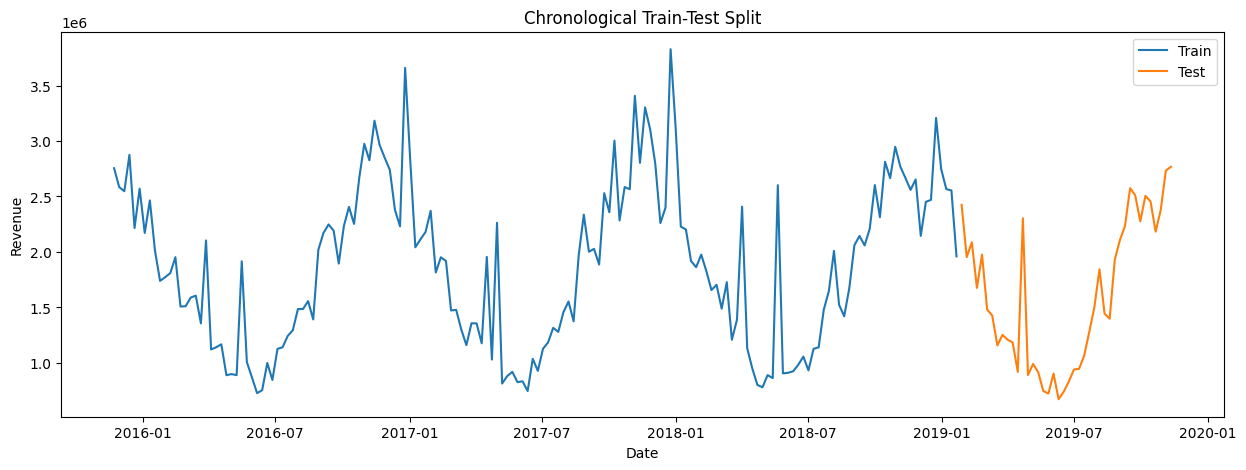

In [6]:
# Chronologischer Train-Test-Split (80/20)
# Identisch zum Bayesian MMM des Kollegen
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print("Total observations:", len(df))
print("Train observations:", len(train_df))
print("Test observations:",  len(test_df))

# Visualisierung des Splits
plt.figure(figsize=(15, 5))

plt.plot(train_df["DATE"], train_df[target], label="Train")
plt.plot(test_df["DATE"],  test_df[target],  label="Test")

plt.title("Chronological Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()

plt.show()

In [7]:
# Scaling (identisch zum Bayesian MMM)
train_model_df = train_df.copy()
test_model_df  = test_df.copy()

# Kleines Epsilon damit keine exakten Nullen entstehen
epsilon = 1e-6
train_model_df[media_cols] = train_model_df[media_cols] + epsilon
test_model_df[media_cols]  = test_model_df[media_cols]  + epsilon

# Media: MaxAbsScaler
media_scaler = MaxAbsScaler()
train_model_df[media_cols] = media_scaler.fit_transform(train_model_df[media_cols])
test_model_df[media_cols]  = media_scaler.transform(test_model_df[media_cols])

# Controls: StandardScaler
control_scaler = StandardScaler()
train_model_df[control_cols] = control_scaler.fit_transform(train_model_df[control_cols])
test_model_df[control_cols]  = control_scaler.transform(test_model_df[control_cols])

# Target
y_train = train_model_df[target].copy()
y_train.name = "y"

y_test = test_model_df[target].copy()
y_test.name = "y"

print("Scaling abgeschlossen.")
print("X_train shape:", train_model_df[media_cols + control_cols].shape)
print("y_train shape:", y_train.shape)

Scaling abgeschlossen.
X_train shape: (166, 7)
y_train shape: (166,)


In [8]:
# Adstock-Transformation als Preprocessing für TabPFN
# Wir verwenden die posterior means aus dem Bayesian MMM des Kollegen
# damit der Vergleich fair bleibt

def geometric_adstock(x: np.ndarray, alpha: float, l_max: int = 8) -> np.ndarray:
    """
    Geometrische Adstock-Transformation.
    alpha : Decay-Parameter (0 = kein Carryover, 1 = kein Decay)
    l_max : maximale Lag-Länge (identisch zum Bayesian MMM: l_max=8)
    """
    x_adstocked = np.zeros_like(x, dtype=float)
    for t in range(len(x)):
        for l in range(l_max):
            if t - l >= 0:
                x_adstocked[t] += (alpha ** l) * x[t - l]
    return x_adstocked


# Adstock-Parameter aus dem Bayesian MMM Posterior (Tabelle des Kollegen)
adstock_alphas = {
    "tv_S":       0.241,
    "ooh_S":      0.572,
    "print_S":    0.428,
    "facebook_S": 0.540,
    "search_S":   0.558,
}

# Transformation auf das gesamte DataFrame VOR dem Split anwenden
df_adstocked = df.copy()

for col, alpha in adstock_alphas.items():
    df_adstocked[col] = geometric_adstock(df[col].values, alpha=alpha, l_max=8)

# Erneut splitten (mit adstockten Werten)
train_adstocked = df_adstocked.iloc[:split_idx].copy()
test_adstocked  = df_adstocked.iloc[split_idx:].copy()

print("Adstock-Transformation abgeschlossen.")
print(train_adstocked[media_cols].describe().round(2))

Adstock-Transformation abgeschlossen.
            tv_S      ooh_S   print_S  facebook_S  search_S
count     166.00     166.00    166.00      166.00    166.00
mean    21982.32  120506.85   7021.09     4656.18  11593.55
std     31827.39  109445.78   6863.46     3920.96   8214.20
min         0.00       0.00      0.00        0.00      0.00
25%      2245.77   43290.10   1925.94     1451.04   5318.62
50%      9793.55   83788.30   5280.09     3780.57   9011.31
75%     27037.97  172773.68  10120.20     7320.59  15760.85
max    158238.37  593949.12  35379.40    17193.67  36338.19


In [9]:
# Scaling der adstock-transformierten Daten
train_model_df = train_adstocked.copy()
test_model_df  = test_adstocked.copy()

# Epsilon
epsilon = 1e-6
train_model_df[media_cols] = train_model_df[media_cols] + epsilon
test_model_df[media_cols]  = test_model_df[media_cols]  + epsilon

# Media: MaxAbsScaler
media_scaler = MaxAbsScaler()
train_model_df[media_cols] = media_scaler.fit_transform(train_model_df[media_cols])
test_model_df[media_cols]  = media_scaler.transform(test_model_df[media_cols])

# Controls: StandardScaler
control_scaler = StandardScaler()
train_model_df[control_cols] = control_scaler.fit_transform(train_model_df[control_cols])
test_model_df[control_cols]  = control_scaler.transform(test_model_df[control_cols])

# Feature-Matrix aufbauen
feature_cols = media_cols + control_cols

X_train = train_model_df[feature_cols].values
X_test  = test_model_df[feature_cols].values

y_train = train_model_df[target].values
y_test  = test_model_df[target].values

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (166, 7)
X_test shape: (42, 7)
y_train shape: (166,)
y_test shape: (42,)


In [10]:
# TabPFN Modell initialisieren und fitten
# Kein MCMC, keine Chains, keine Priors — ein einziger Aufruf

regressor = TabPFNRegressor()

regressor.fit(X_train, y_train)

print("TabPFN Fitting abgeschlossen!")

00:03 Fitting... Done!
TabPFN Fitting abgeschlossen!


In [11]:
# Out-of-Sample Prediction (identisch zur Struktur des Kollegen)
y_pred_mean_test_rescaled = regressor.predict(X_test)

print("Vorhersage abgeschlossen!")
print("Erste 5 Vorhersagen:", y_pred_mean_test_rescaled[:5])
print("Erste 5 Actual:     ", y_test[:5])

00:12 Predicting... Done!
Vorhersage abgeschlossen!
Erste 5 Vorhersagen: [2374804.    1990113.375 2007785.625 1689183.375 1902930.875]
Erste 5 Actual:      [2424486.66666667 1953060.         2086935.         1675816.66666667
 1976413.33333333]


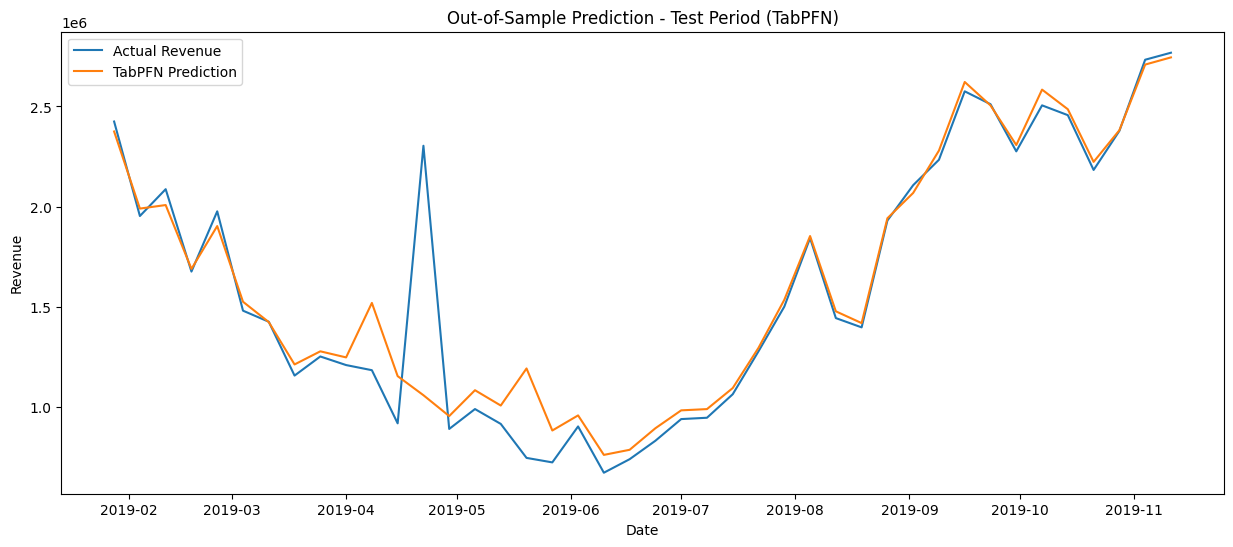

Forecast Accuracy Results
MAE:  94,207.08
RMSE: 219,723.31
MAPE: 7.41%


In [12]:
# Plot: Actual vs. TabPFN Prediction
plt.figure(figsize=(15, 6))

plt.plot(test_df["DATE"], y_test, label="Actual Revenue")
plt.plot(test_df["DATE"], y_pred_mean_test_rescaled, label="TabPFN Prediction")

plt.title("Out-of-Sample Prediction - Test Period (TabPFN)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()

plt.show()

# Forecast Accuracy Metrics (identisch zum Kollegen)
mae  = mean_absolute_error(y_test, y_pred_mean_test_rescaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_mean_test_rescaled))
mape = mean_absolute_percentage_error(y_test, y_pred_mean_test_rescaled) * 100

print("Forecast Accuracy Results")
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

In [13]:
# Channel Contribution Analysis (identisch zum Kollegen)
# Wir berechnen den Effekt jedes Kanals via Permutation

channel_contribution = {}

for channel in media_cols:
    # Baseline: Vorhersage mit originalem X_test
    y_baseline = regressor.predict(X_test)

    # Counterfactual: Kanal auf Null setzen
    X_test_zeroed = X_test.copy()
    col_idx = feature_cols.index(channel)
    X_test_zeroed[:, col_idx] = 0

    y_counterfactual = regressor.predict(X_test_zeroed)

    # Contribution = Differenz
    contribution = (y_baseline - y_counterfactual).sum()
    channel_contribution[channel] = contribution

    print(f"{channel}: {contribution:,.2f}")

00:00 Predicting... |

00:01 Predicting... Done!
00:12 Predicting... Done!
tv_S: 2,762,697.31
00:00 Predicting... -

00:01 Predicting... Done!
00:03 Predicting... Done!
ooh_S: 72,596.81
00:00 Predicting... -

00:11 Predicting... Done!
00:03 Predicting... Done!
print_S: 1,281,912.81
00:00 Predicting... -

00:01 Predicting... Done!
00:04 Predicting... Done!
facebook_S: 1,145,882.19
00:00 Predicting... -

00:01 Predicting... Done!
00:04 Predicting... Done!
search_S: 800,462.81


Channel Contribution:
tv_S          2.762697e+06
print_S       1.281913e+06
facebook_S    1.145882e+06
search_S      8.004628e+05
ooh_S         7.259681e+04
dtype: float64


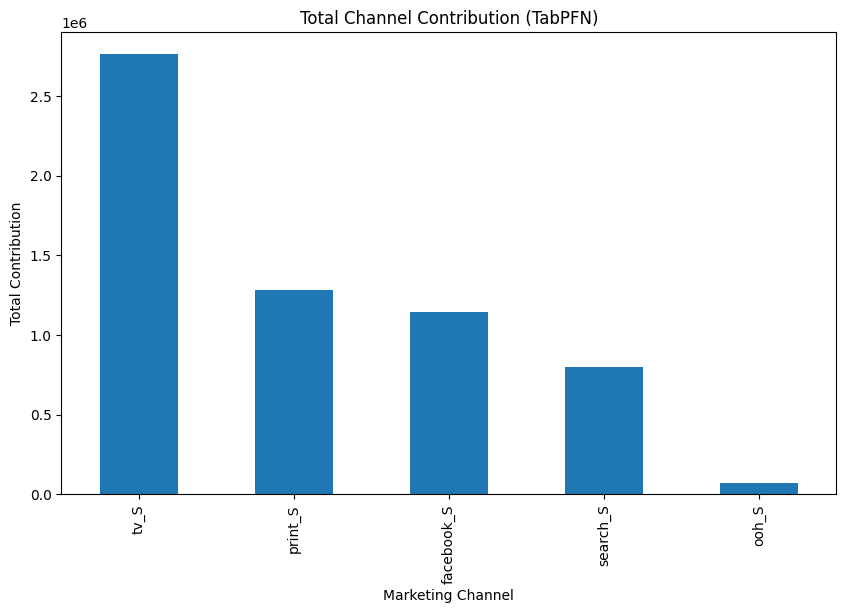


Estimated ROAS by Channel (TabPFN):
tv_S          1.044983e+06
print_S       2.425615e+05
facebook_S    1.126794e+05
ooh_S         5.742865e+04
search_S      3.591224e+04
dtype: float64


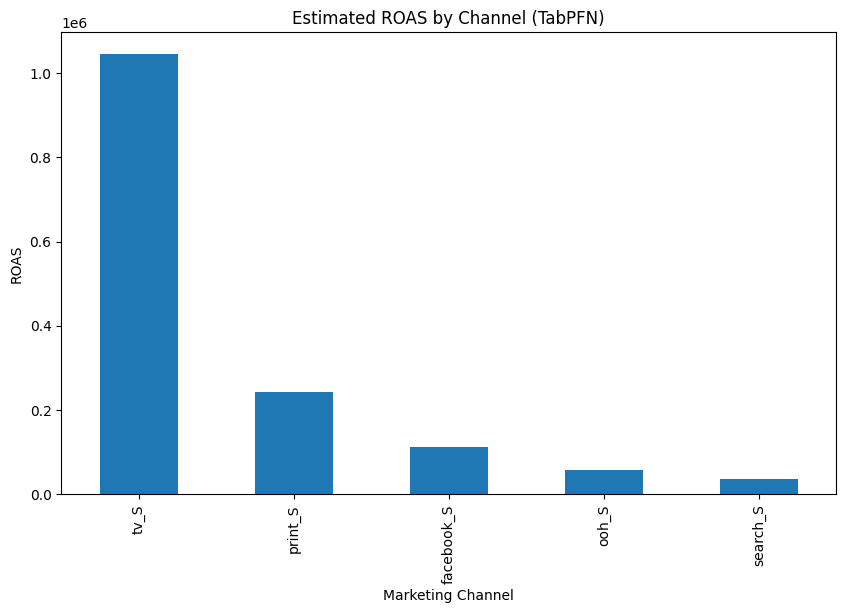

In [14]:
# Channel Contribution als Series (identisch zum Kollegen)
total_channel_contribution = pd.Series(channel_contribution).sort_values(ascending=False)

print("Channel Contribution:")
print(total_channel_contribution)

# Plot
plt.figure(figsize=(10, 6))
total_channel_contribution.plot(kind="bar")
plt.title("Total Channel Contribution (TabPFN)")
plt.xlabel("Marketing Channel")
plt.ylabel("Total Contribution")
plt.show()

# ROAS (identisch zum Kollegen)
total_spend = test_model_df[media_cols].sum()
roas = total_channel_contribution / total_spend
roas = roas.sort_values(ascending=False)

print("\nEstimated ROAS by Channel (TabPFN):")
print(roas)

# Plot
plt.figure(figsize=(10, 6))
roas.plot(kind="bar")
plt.title("Estimated ROAS by Channel (TabPFN)")
plt.xlabel("Marketing Channel")
plt.ylabel("ROAS")
plt.show()